# LDA Model
## Marissa Burton

### Import packages

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF

### Set OHCO

In [33]:
model_type = 'lda'
OHCO = ['era','book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:4]
CHAP = OHCO[:3]
BOOK = OHCO[:2]
ERA = OHCO[:1]
BAG = CHAP

### Load in CORPUS

In [34]:
CORPUS = pd.read_csv('data/CORPUS.csv')

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_29069/1873822874.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  CORPUS = pd.read_csv('data/CORPUS.csv')


### Create DOCS table and filter for nouns

In [35]:
DOCS = CORPUS.groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

### Set stop words

In [36]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))

### Create Vector Space

In [37]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

17  abandoned  able  abroad  \
era                       book_id chap_num                                
classical/romantic gothic 6087    1          0          0     0       0   
                                  2          0          0     0       0   
                                  3          0          0     0       0   
                                  4          0          0     0       0   
                          41445   1          0          0     0       0   
...                                         ..        ...   ...     ...   
victorian gothic          345     24         0          0     4       0   
                                  25         1          0     0       0   
                                  26         0          0     2       0   
                                  27         0          0     1       0   
                          1952    0          0          0     4       0   

                                            abruptly  absence  absent  \
era                       book_id chap_num                              
classical/romantic gothic 6087    1                0        0       0   
                                  2                0        0       0   
                                  3                0        0       0   
                                  4                1        1       0   
                          41445   1                0        0       1   
...                                              ...      ...     ...   
victorian gothic          345     24               0        0       0   
                                  25               0        0       0   
                                  26               0        0       0   
                                  27               0        0       0   
                          1952    0                0        0       0   

                                            absolute  absolutely  absorbed  \
era                       book_id chap_num                                   
classical/romantic gothic 6087    1                0           0         0   
                                  2                0           0         0   
                                  3                0           0         0   
                                  4                0           0         3   
                          41445   1                0           0         0   
...                                              ...         ...       ...   
victorian gothic          345     24               0           0         0   
                                  25               1           0         0   
                                  26               0           0         0   
                                  27               0           0         0   
                          1952    0                0           1         0   

                                            ...  years  yellow  yesterday  \
era                       book_id chap_num  ...                             
classical/romantic gothic 6087    1         ...      1       0          0   
                                  2         ...      0       0          0   
                                  3         ...      1       1          0   
                                  4         ...      1       0          0   
                          41445   1         ...      9       0          0   
...                                         ...    ...     ...        ...   
victorian gothic          345     24        ...      1       0          2   
                                  25        ...      0       0          1   
                                  26        ...      1       0          0   
                                  27        ...      2       1          2   
                          1952    0         ...      1       8          0   

                                            yield  yielded  young  younger  \
era                    

### Generate Model

In [38]:
n_topics = 20
max_iter = 100
n_top_terms = 5
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [39]:
topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

### THETA

In [40]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap='Blues')

### PHI

In [41]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap='Blues')

term_str,advance,divine,passed,sacrifice,excess,mouth,sharply,creation,dawn,hour
topic_id,,,,,,,,,,
T00,1.117174,0.050000,3.503187,0.050000,0.050000,12.179549,0.050000,0.050000,0.050000,3.478072
T01,0.050000,0.050000,56.661646,0.050000,5.910083,0.050000,0.050000,0.050000,1.903172,14.417569
T02,0.050000,0.050000,2.112404,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T03,0.050000,0.050000,3.355840,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T04,4.714933,0.050000,39.186013,0.050000,0.050000,21.081697,0.050000,0.050000,27.149728,45.531650
T05,0.050000,0.050000,17.069644,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,9.033976
T06,1.618984,1.387344,1.996305,0.050000,1.089578,0.050000,0.050000,0.050000,0.050000,1.286300
T07,0.050000,5.303472,19.998180,0.050000,0.050000,12.972022,0.050000,0.050000,0.050000,3.224452
T08,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000


### TOPICS

In [42]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,helsing van arthur lucy nan
T01,emily nan madame valancourt aunt
T02,cottage old science wood young
T03,richard moncharmin envelope pocket giry
T04,nan shall come came went
T05,old house great took white
T06,lord sister mind room soon
T07,christine raoul erik voice persian
T08,rule stupid permit draught track


#### TOPICS sorted by document weights

In [43]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

,top_terms,doc_weight_sum,term_freq
topic_id,,,
T04,nan shall come came went,19.778398,0.181615
T13,house doctor door room mrs,14.823565,0.129034
T07,christine raoul erik voice persian,14.055333,0.069046
T17,nan father moment life words,11.337117,0.121649
T16,father elizabeth death shall life,10.635112,0.051801
T05,old house great took white,8.201247,0.046994
T01,emily nan madame valancourt aunt,7.631423,0.056600
T15,nan lord sir shall thou,7.234179,0.151922
T11,st aubert nan emily woods,7.174620,0.062648


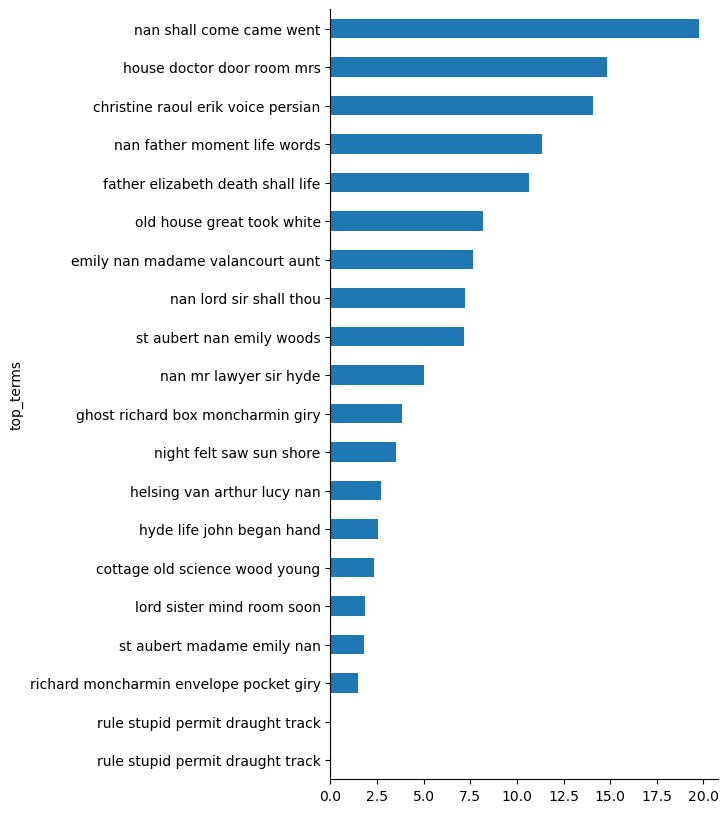

In [44]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

### Export tables

In [45]:
DOCS.to_csv('data/DOCS.csv')

In [46]:
THETA.to_csv('data/THETA.csv')
PHI.to_csv('data/PHI.csv')
TOPICS.to_csv('data/TOPICS.csv')

In [47]:
DTM.to_csv('data/LDA_DTM.csv')